In [1]:
import sys
print(f"Success! You are using Python {sys.version}")

Success! You are using Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [ ]:
import pandas as pd

file_path = r'C:\Users\Dell\Documents\ANALYTICS PRACTICE\PROJECT\Finance Project\clean_bank_data.csv'

df = pd.read_csv(file_path)

df.head()

,customer_id,credit_score,country,gender,age,tenure,formatted_balance,formatted_salary,balance,estimated_salary,products_number,credit_card,active_member,churn,Age_Group
0,15634602,619,France,Female,42,2,$0.00,"$101,348.88",0.00,101348.88,1,1,1,1,Mid-Career
1,15647311,608,Spain,Female,41,1,"$83,807.86","$112,542.58",83807.86,112542.58,1,0,1,0,Mid-Career
2,15619304,502,France,Female,42,8,"$159,660.80","$113,931.57",159660.80,113931.57,3,1,0,1,Mid-Career
3,15701354,699,France,Female,39,1,$0.00,"$93,826.63",0.00,93826.63,2,0,0,0,Mid-Career
4,15737888,850,Spain,Female,43,2,"$125,510.82","$79,084.10",125510.82,79084.10,1,1,1,0,Mid-Career


Matplotlib is building the font cache; this may take a moment.


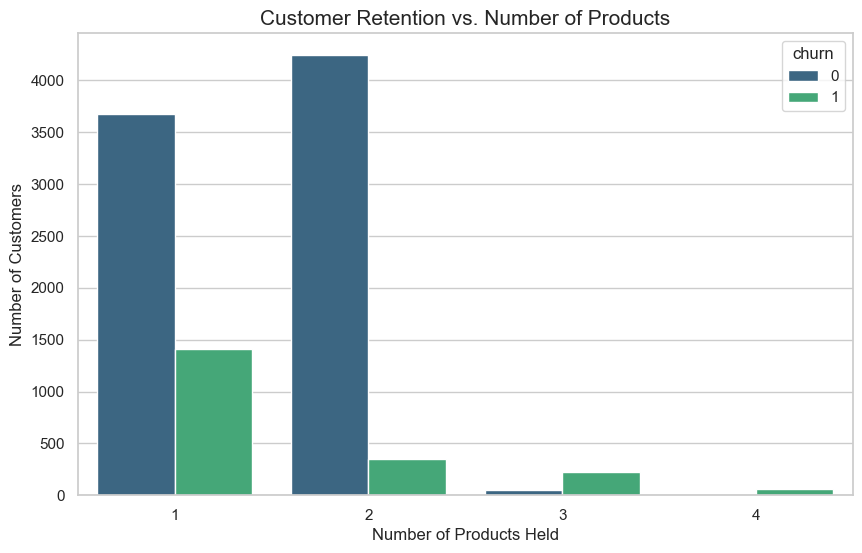

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='products_number', hue='churn', palette='viridis')

# Add labels and title
plt.title('Customer Retention vs. Number of Products', fontsize=15)
plt.xlabel('Number of Products Held', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()

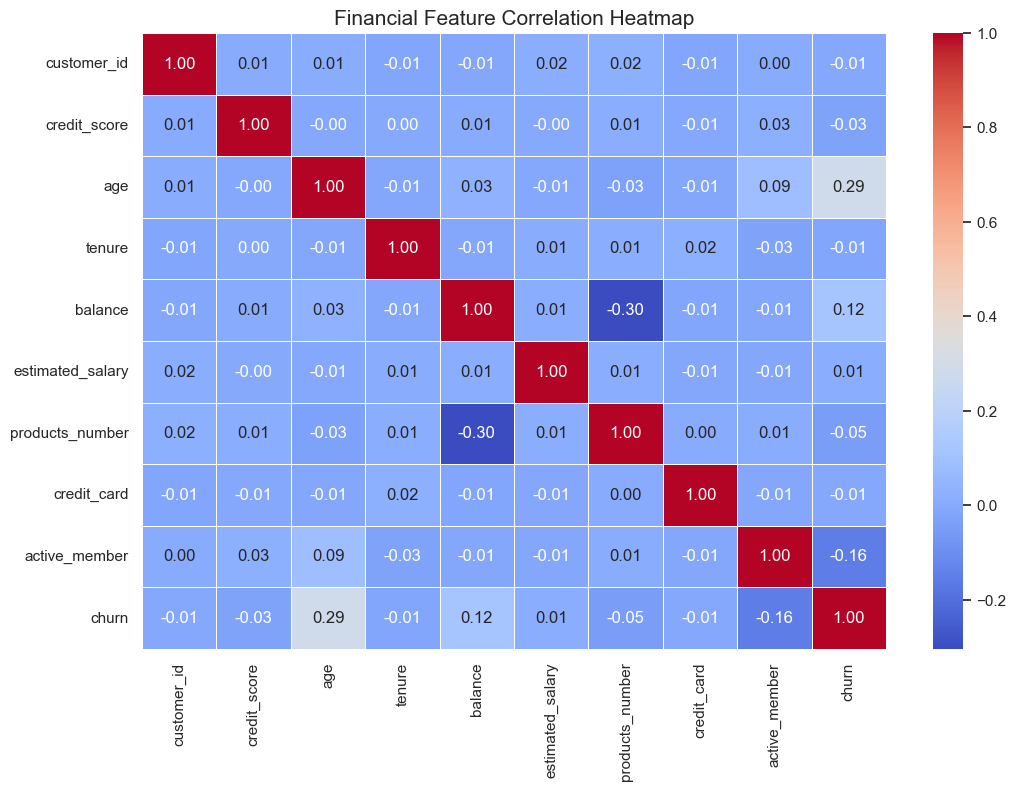

In [4]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Financial Feature Correlation Heatmap', fontsize=15)
plt.show()

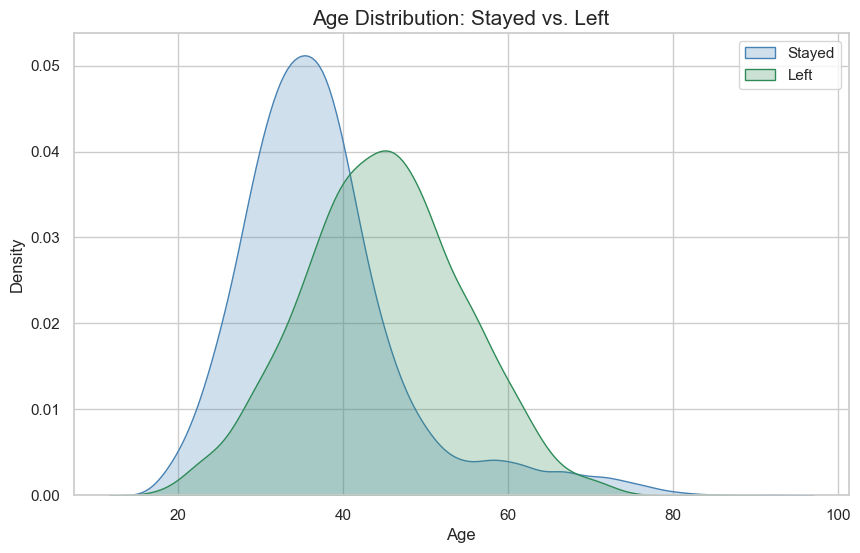

In [6]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['churn'] == 0], x='age', label='Stayed', fill=True, color='steelblue')
sns.kdeplot(data=df[df['churn'] == 1], x='age', label='Left', fill=True, color='seagreen')

plt.title('Age Distribution: Stayed vs. Left', fontsize=15)
plt.xlabel('Age')
plt.legend()
plt.show()

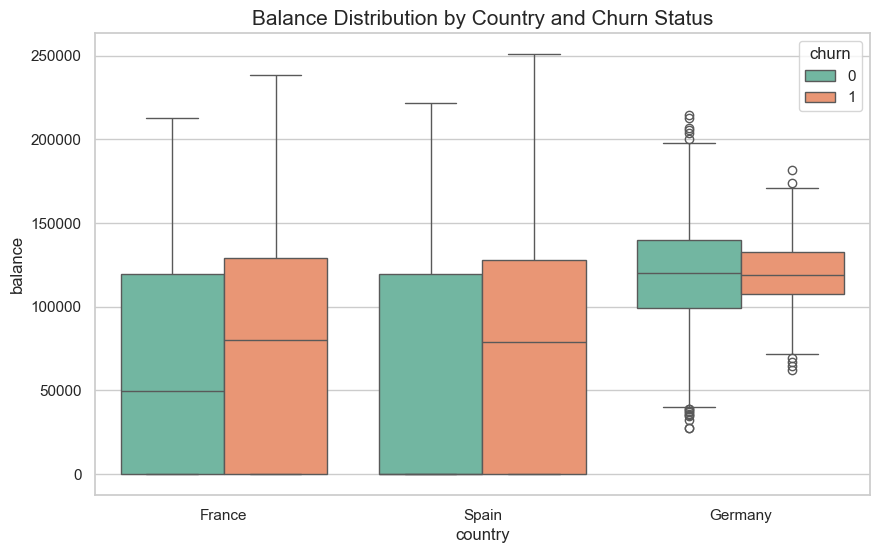

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='country', y='balance', hue='churn', data=df, palette='Set2')

plt.title('Balance Distribution by Country and Churn Status', fontsize=15)
plt.show()

In [10]:
# 1. Convert Gender to numbers (1 for Female, 0 for Male)
# Use .get() or a check to handle if it's already converted
if df['gender'].dtype == 'O': # 'O' means Object/String
    df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# 2. Drop the "Formatted" and "Text" columns that the model can't read
# We keep 'balance' and 'estimated_salary' because those are already pure numbers
cols_to_drop = [
    'customer_id', 
    'churn', 
    'formatted_balance', 
    'formatted_salary', 
    'Age_Group'
]

# 3. Define our Features (X) and our Target (y)
X = df.drop(columns=cols_to_drop)
y = df['churn']

# Double-check: All columns in X should now be float or int
print("Columns being sent to the model:")
print(X.dtypes)

print("\nData Prepared successfully!")

Columns being sent to the model:
credit_score          int64
gender                int64
age                   int64
tenure                int64
balance             float64
estimated_salary    float64
products_number       int64
credit_card           int64
active_member         int64
country_Germany        bool
country_Spain          bool
dtype: object

Data Prepared successfully!


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Model (Random Forest is great for beginners)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

print("Model Training Complete!")
print(classification_report(y_test, predictions))

Model Training Complete!
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1632
           1       0.77      0.49      0.60       368

    accuracy                           0.88      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.87      0.88      0.87      2000



C:\Users\Dell\AppData\Local\Temp\ipykernel_12836\584464834.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


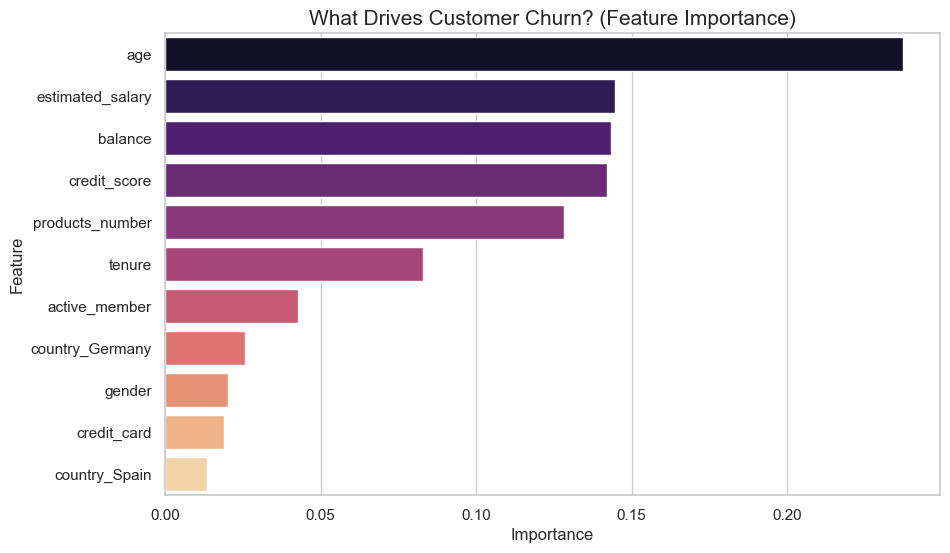

In [12]:
import numpy as np

# 1. Get the importance of each feature
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Plot it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('What Drives Customer Churn? (Feature Importance)', fontsize=15)
plt.show()